In [1]:
from OOP_so_far import RunSSA, ModuleProperties, CombiningModules, plot_combined_conductance
from sympy import *
import numpy as np
import time

/Users/willalston/Desktop/Msci_Project/git_repos/students/Will/Gillespie_simulations/OOP_so_far.py:1269: SyntaxWarning: invalid escape sequence '\m'
  chem_pot = symbols(f"\mu_{species_symbol}")


# Define Module 

In [2]:
# MODULE 1


SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["Ea", "EaS","EaS2","S","Na"]

num_internal_species = 3


# MODULE 2

SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["Eb", "EbF", "EbW", "Eb*", "Na", "Nb", "F", "W"]

num_internal_species2 = 4



# Prepare for simulation

In [3]:
# Use ModuleProperties to create module variables for our CRNs

module1_for_simulating = ModuleProperties(SM, 3, species_names)

module2_for_simulating = ModuleProperties(SM2, 4, species_names2)


# Define the initial conditions we need to simulate our CRNs using the SSA

simulation_length = 400.0

burn_in_time = 100.0 # This quantity is important for ensuring we are sampling the steady state - it is best to first pick any value
                     # burn_in_time < simulation_length, visually see where the transient state ends on the counts plot, and then
                     # adjust this value appropriately for sampling runs.

initial_counts = [350, 350, 350, 50, 50]

rates = 0.1 * np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])



initial_counts2 = [350, 350, 350, 350, 50, 50, 50, 50]

rates2 = 0.1 * np.array([0.01, 1.0, 1.0, 0.5, 1.5, 0.01, 0.01, 1.0, 1.2, 0.01])

# Create simulation module variables

SIM1 = RunSSA(module1_for_simulating, initial_counts, rates, simulation_length, burn_in_time)

SIM2 = RunSSA(module2_for_simulating, initial_counts2, rates2, simulation_length, burn_in_time)



# Plot species population trajectories over time

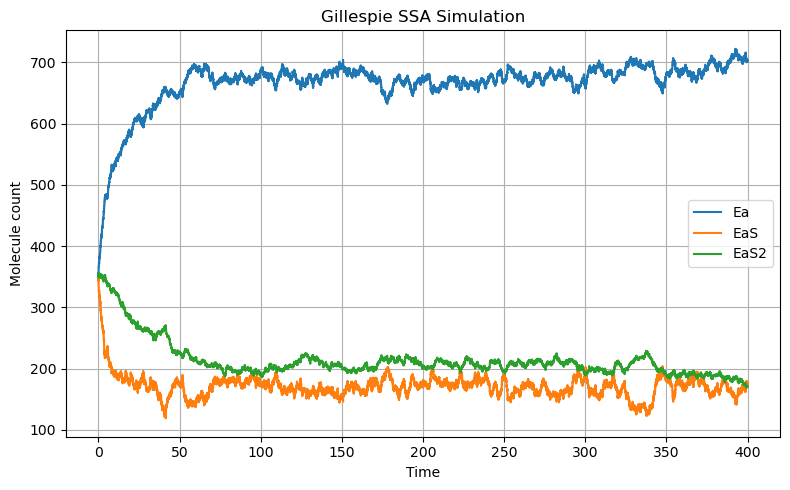

In [4]:
# 1) Change store_trajectories = False (default = True) to skip trajectory plotting. This offers up to 100x speed up.
#
# 2) Add an explicit set of starting populations as a list (in same order as 'species_names' used in ModuleProperties),
#    default is to use pre-defined list 'initial_counts' in RunSSA.

SIM1.run_SSA_and_plot_counts(store_trajectories=True, starting_pops=None)

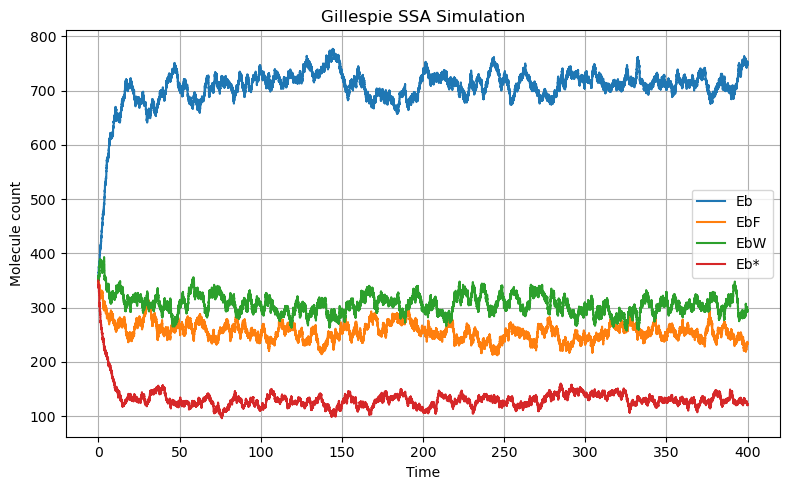

In [5]:
SIM2.run_SSA_and_plot_counts(True)

# Plot the distribution of currents and forces over a set number of iterations 

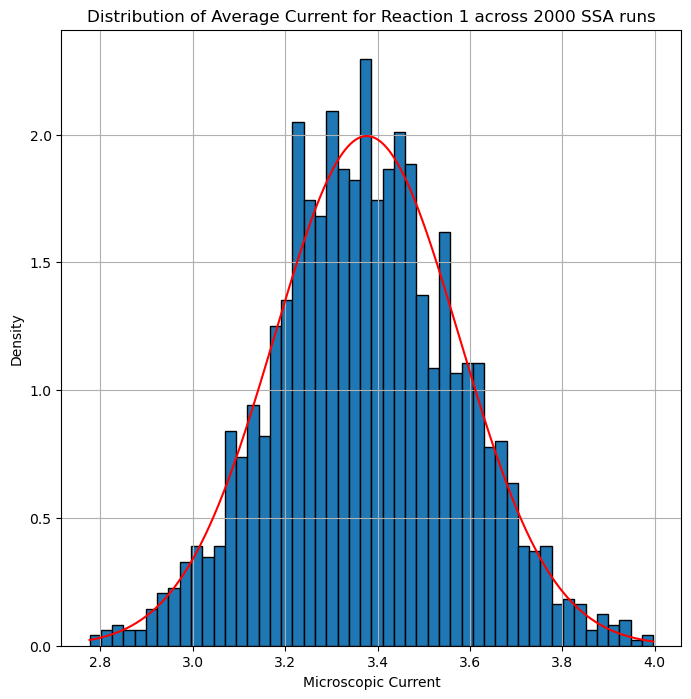

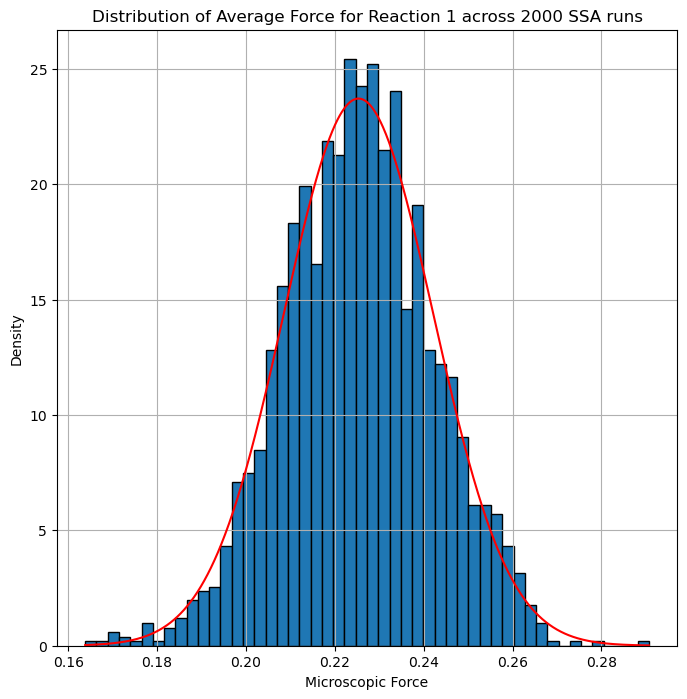

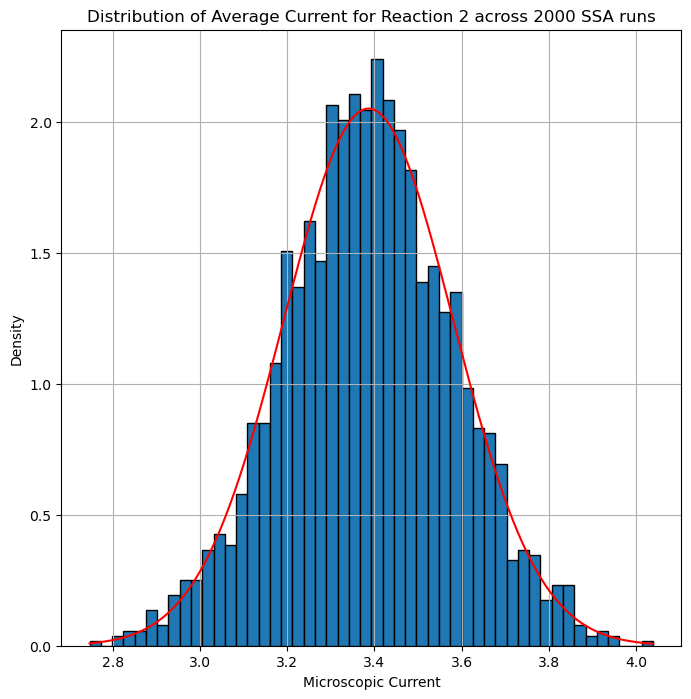

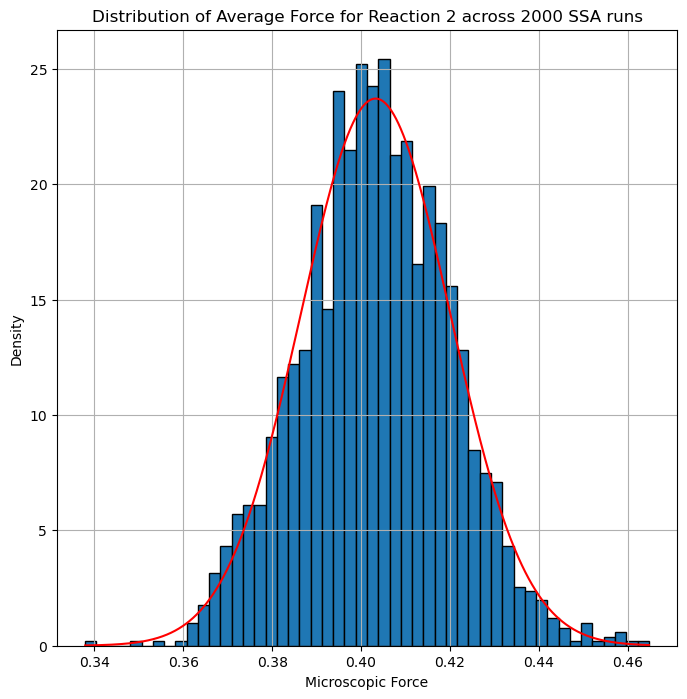

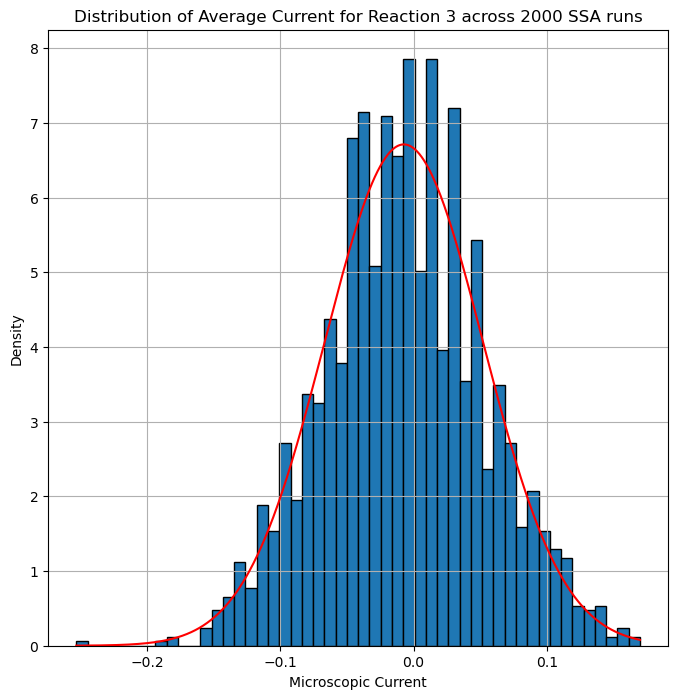

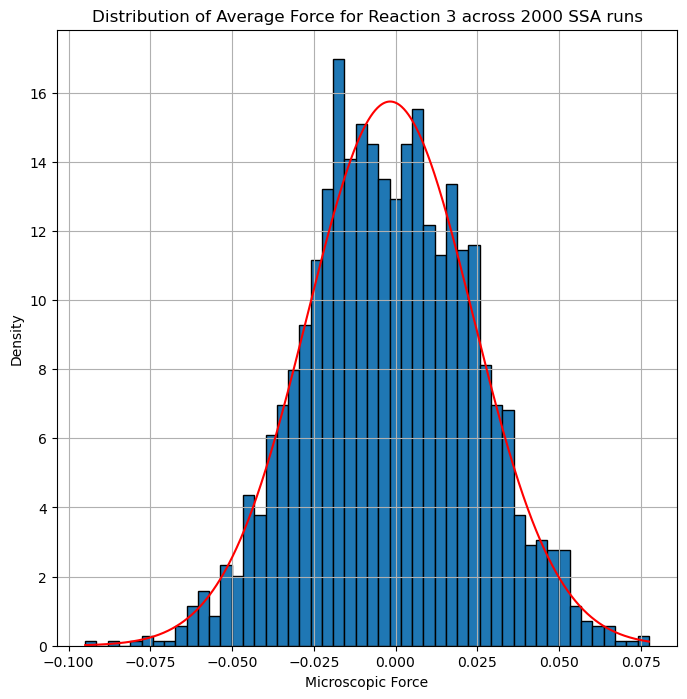

In [6]:
# This attribute allows us to see how well the currents and forces converge to a Gaussian for a different number of SSA repeats. The plotted data is time averaged current and force across all
# the reactions in the CRN after each individual run of SSA (out of num_iterations). This is helpful for determining how many iterations we should run
# when we want to average these values. The default values are bins=50, num_iterations = 50, Gaussian_points = 1000. Reactions are in order of the columns of the inputted stoichiometric matrix.

SIM1.plot_gaussian_comparison(bins=50, num_iterations=2000, Gaussian_points=1000)


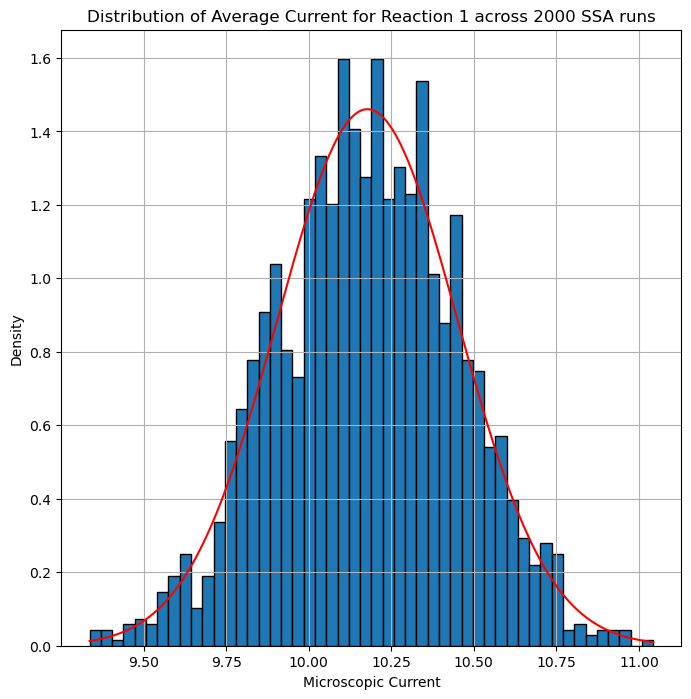

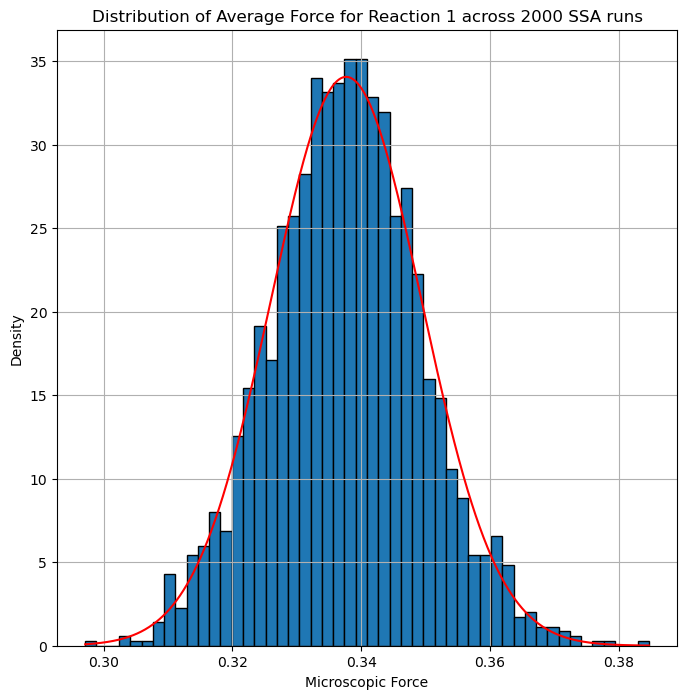

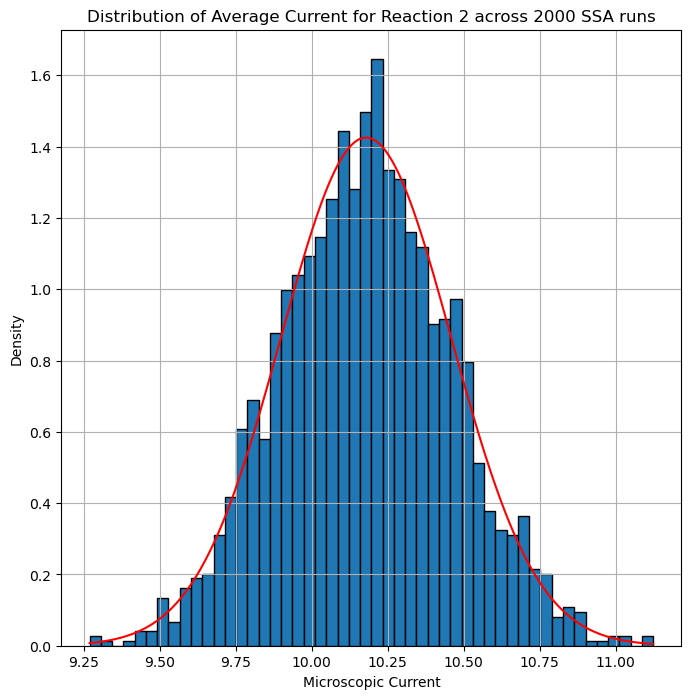

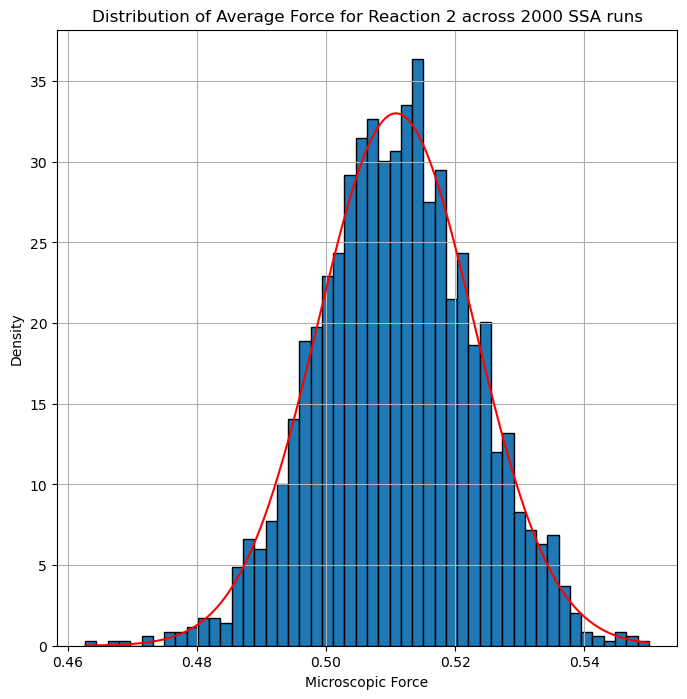

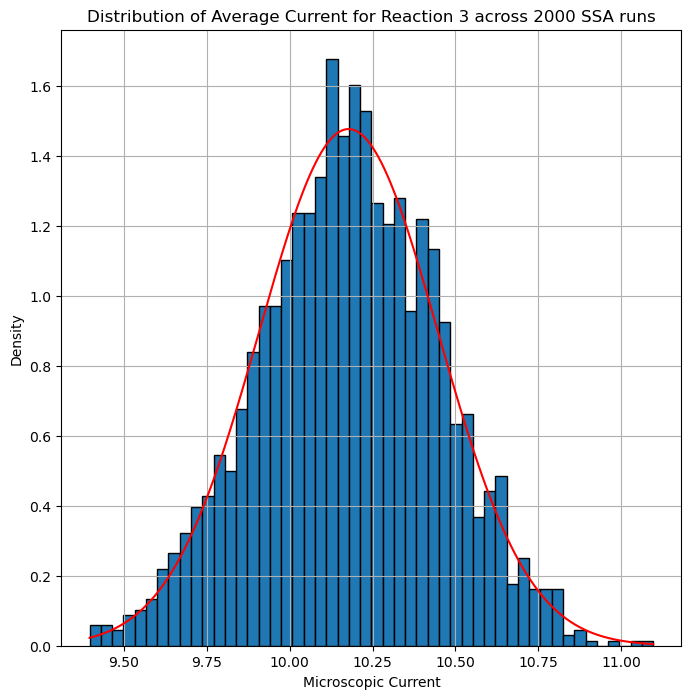

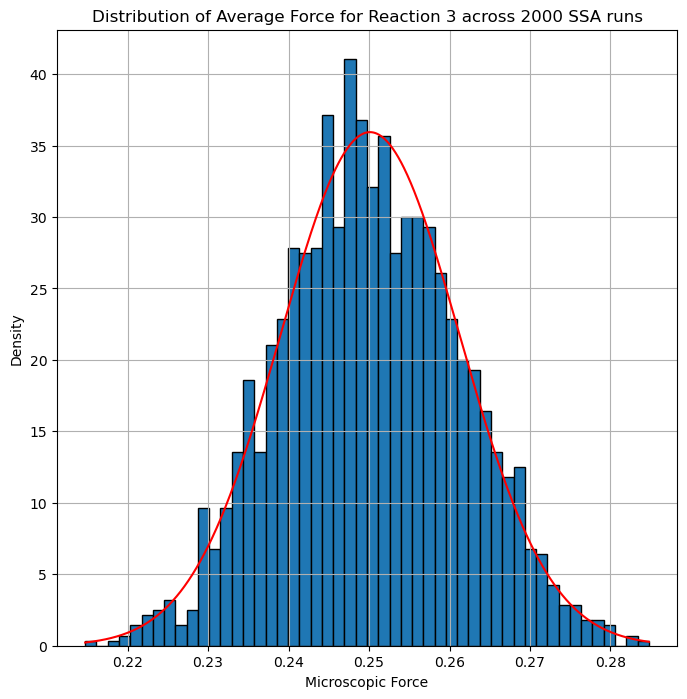

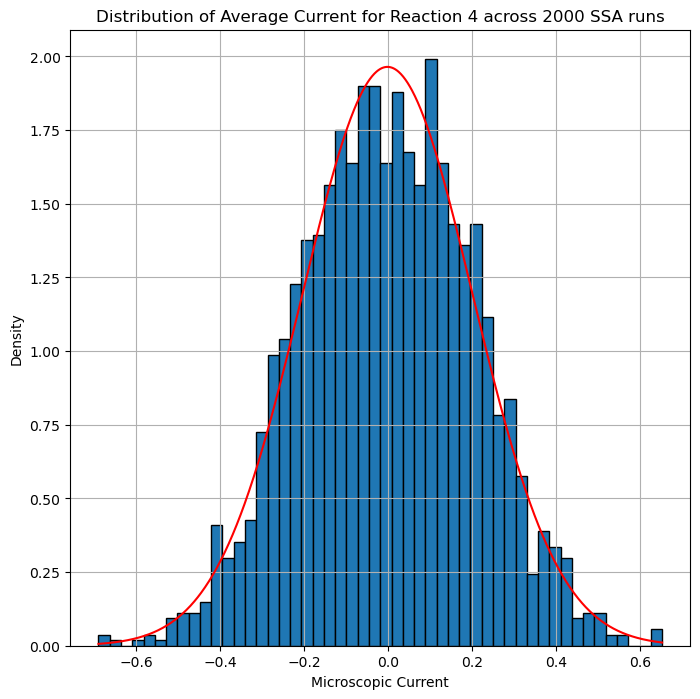

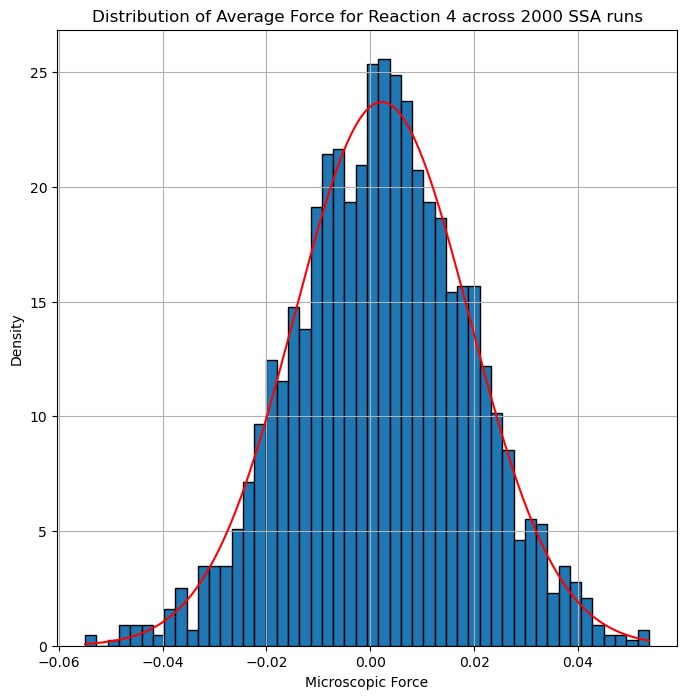

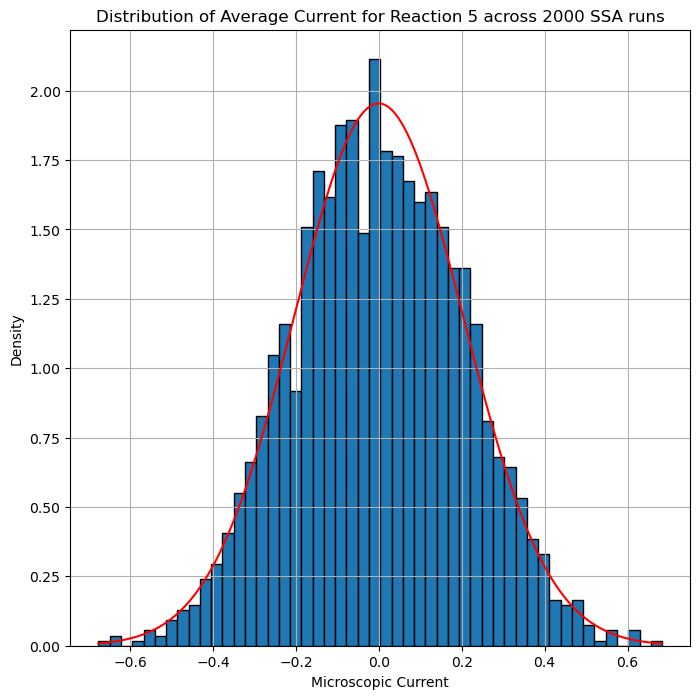

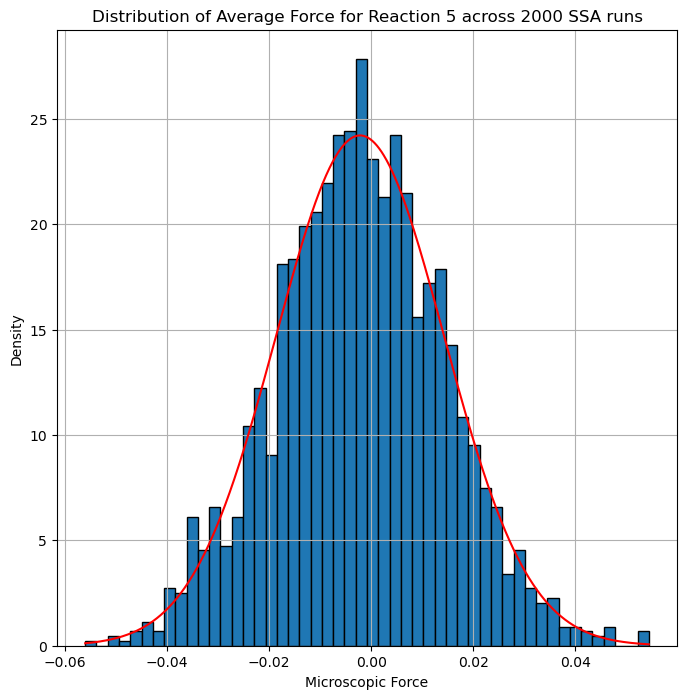

In [7]:
SIM2.plot_gaussian_comparison(bins=50, num_iterations=2000, Gaussian_points=1000)

# Create I-F curves for the reactions in the module for a varied initial species count

## Compute I-F data from simulation

In [4]:
# Run SSA sweeps over a varying initial count. In this line, we vary the species at position 3 in species_names ('S') with integer 
# values between 50 and 500, running 40 iterations for each value of 'S'. We opt for 'verbose=True' so that we might track the progress
# through the various 'S' values. The 'covariance_reaction_indicies' tells the code which currents to sample the covariance between,
# this should be the set of currents in the fundamental current vector. For module 1, I = j1, so we set this = [0]. For module 2,
# I_ = (j3, j5) so we choose = [2, 4].

# If desire, one can change multiple species by using a list of indices e.g. [1,3] changes species at index 0 and 2, and passing a list
# of lists of values to vary through (these must be the same length).

# Module 1

SIM1.run_IF_sweep(
    
        species_index=3,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=50, 
        covariance_reaction_indices=[0],   
        verbose=True)

# Module 2

SIM2.run_IF_sweep(
    
        species_index=4,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=50, 
        covariance_reaction_indices=[2,4],   
        verbose=True)


Sweep 1/50  ([S] = 50)
Sweep 2/50  ([S] = 59)
Sweep 3/50  ([S] = 68)
Sweep 4/50  ([S] = 77)
Sweep 5/50  ([S] = 86)
Sweep 6/50  ([S] = 95)
Sweep 7/50  ([S] = 105)
Sweep 8/50  ([S] = 114)
Sweep 9/50  ([S] = 123)
Sweep 10/50  ([S] = 132)
Sweep 11/50  ([S] = 141)
Sweep 12/50  ([S] = 151)
Sweep 13/50  ([S] = 160)
Sweep 14/50  ([S] = 169)
Sweep 15/50  ([S] = 178)
Sweep 16/50  ([S] = 187)
Sweep 17/50  ([S] = 196)
Sweep 18/50  ([S] = 206)
Sweep 19/50  ([S] = 215)
Sweep 20/50  ([S] = 224)
Sweep 21/50  ([S] = 233)
Sweep 22/50  ([S] = 242)
Sweep 23/50  ([S] = 252)
Sweep 24/50  ([S] = 261)
Sweep 25/50  ([S] = 270)
Sweep 26/50  ([S] = 279)
Sweep 27/50  ([S] = 288)
Sweep 28/50  ([S] = 297)
Sweep 29/50  ([S] = 307)
Sweep 30/50  ([S] = 316)
Sweep 31/50  ([S] = 325)
Sweep 32/50  ([S] = 334)
Sweep 33/50  ([S] = 343)
Sweep 34/50  ([S] = 353)
Sweep 35/50  ([S] = 362)
Sweep 36/50  ([S] = 371)
Sweep 37/50  ([S] = 380)
Sweep 38/50  ([S] = 389)
Sweep 39/50  ([S] = 398)
Sweep 40/50  ([S] = 408)
Sweep 41/50  ([

(array([[19.22647414, -5.19328133, 19.10980864, 24.40642227, 24.31308987],
        [19.02636452, -5.39324769, 18.9796986 , 24.41627893, 24.42627877],
        [19.37665547, -4.96999713, 19.39998879, 24.36665258, 24.38331924],
        [19.30286774, -4.81655049, 19.24286918, 24.10608521, 24.09608546],
        [19.0899742 , -5.25332623, 19.16997409, 24.36663373, 24.26663387],
        [19.31316062, -4.66662493, 19.37982669, 23.98311886, 24.00645198],
        [18.61320934, -5.23329847, 18.7798749 , 23.85317443, 23.89650748],
        [19.04999524, -5.16999871, 19.05999524, 24.16332729, 24.18332729],
        [18.95983018, -5.12995405, 19.00649643, 24.10645075, 24.13311718],
        [19.02973876, -5.0699304 , 18.97973945, 24.05633643, 24.07966944],
        [18.8430827 , -5.10993203, 18.78641679, 23.96968118, 23.94968144],
        [18.82653558, -4.78996665, 18.98320116, 23.60316899, 23.84650063],
        [19.20308304, -4.7132719 , 19.11308422, 23.94968784, 23.90635508],
        [19.17975062, -5.

In [9]:
# Module 2

# SIM2.run_IF_sweep(
    
#         species_index=4,
#         count_values=np.linspace(50,500,50,dtype='int'),
#         total_iterations=10, 
#         covariance_reaction_indices=[2,4],   
#         verbose=True)

In [10]:
SIM2.species_names

['Eb', 'EbF', 'EbW', 'Eb*', 'Na', 'Nb', 'F', 'W']

## Plot the curves

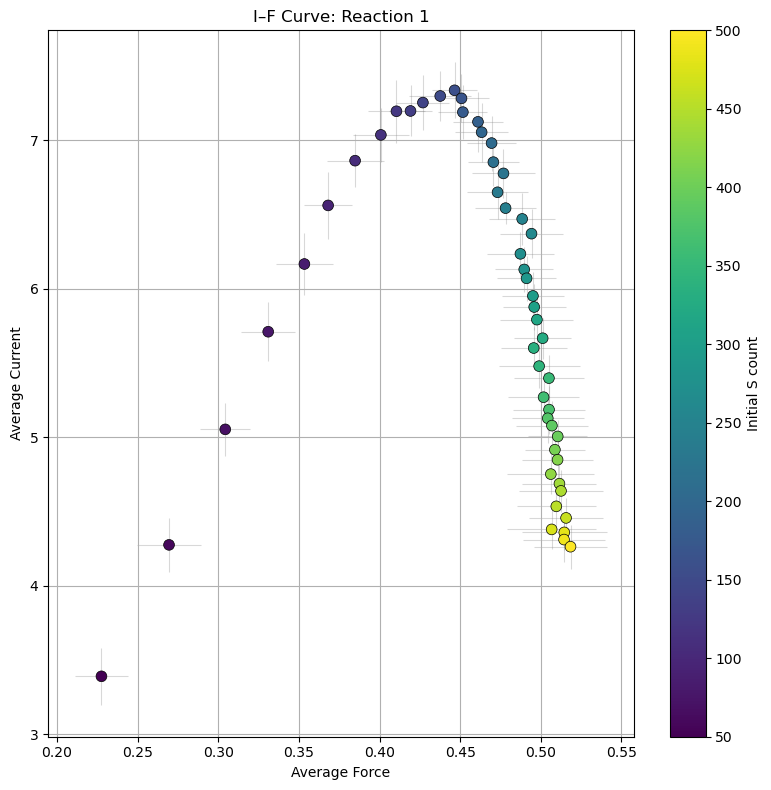

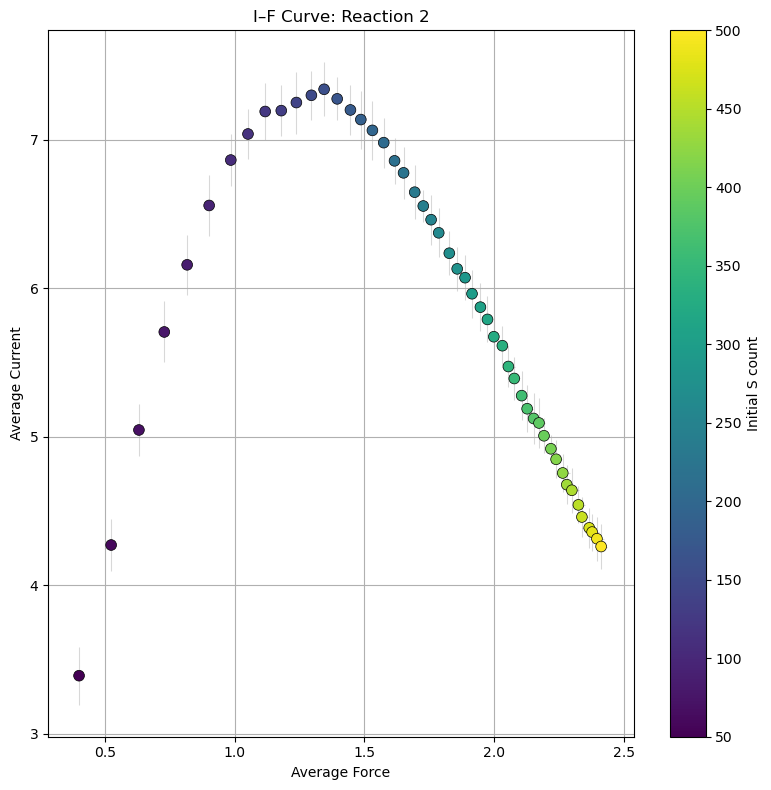

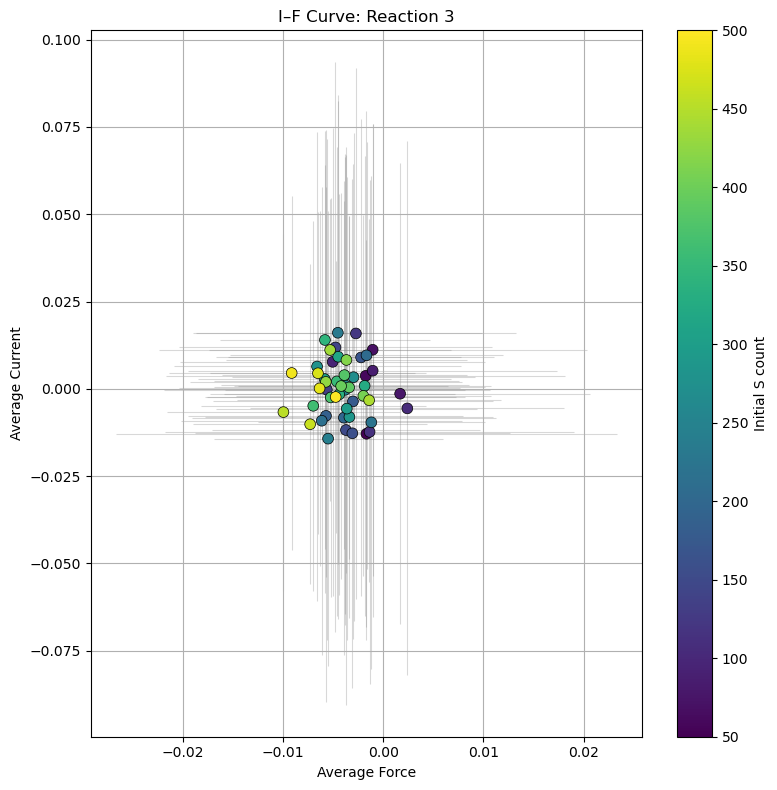

In [5]:
# Now, we can plot the resulting I-F curves. We can select which to plot with 'reaction_indices', note that 'reaction 1' has index 0.
# Default is to plot all reactions. We can opt to plot any analytical results we may have calculated by passing these as lists into
# 'analytical_currents' and 'analytical_forces'.

# Module 1

SIM1.plot_IF_curves(

        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )

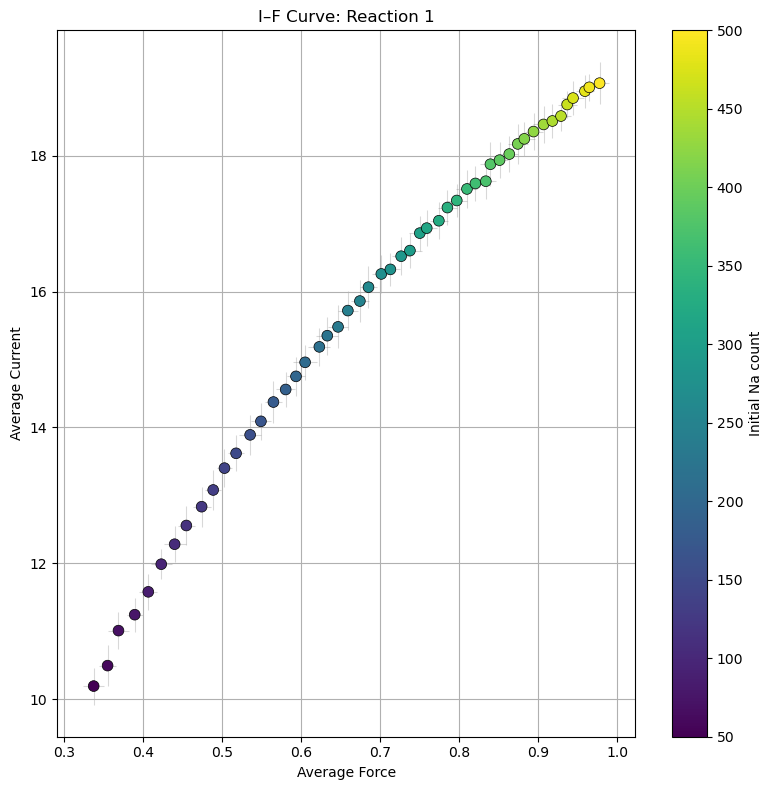

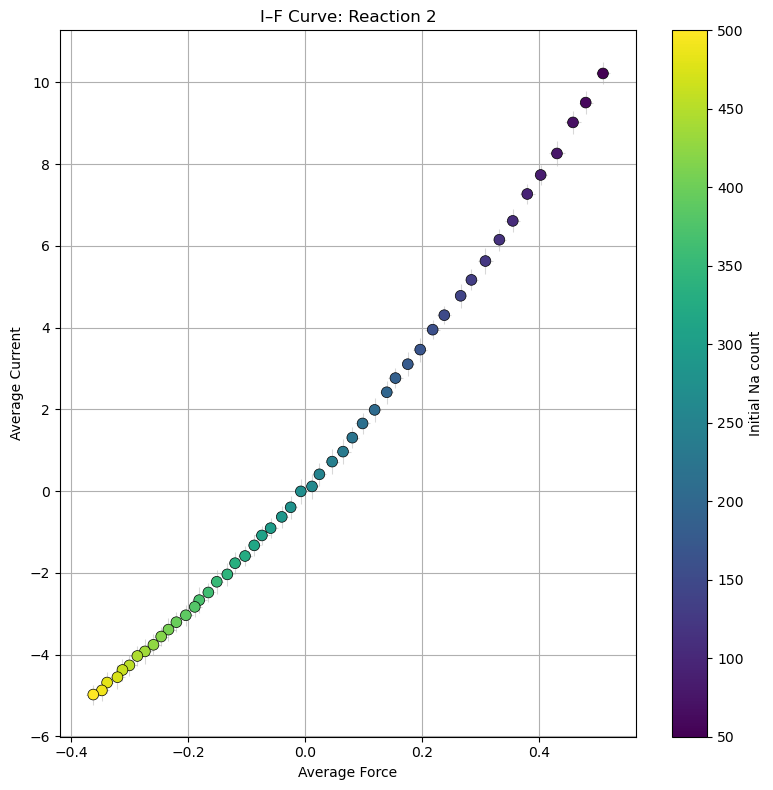

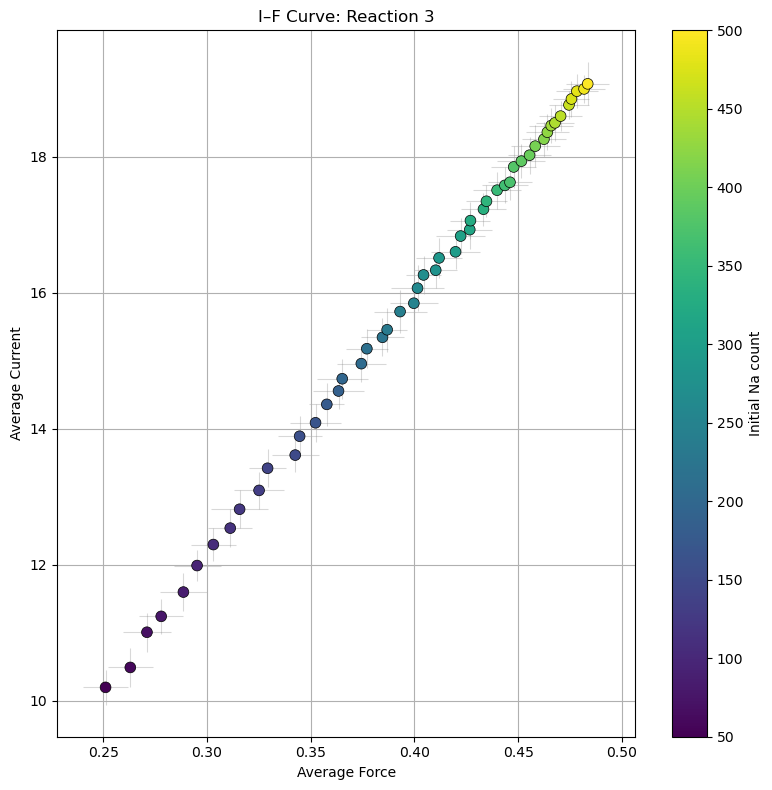

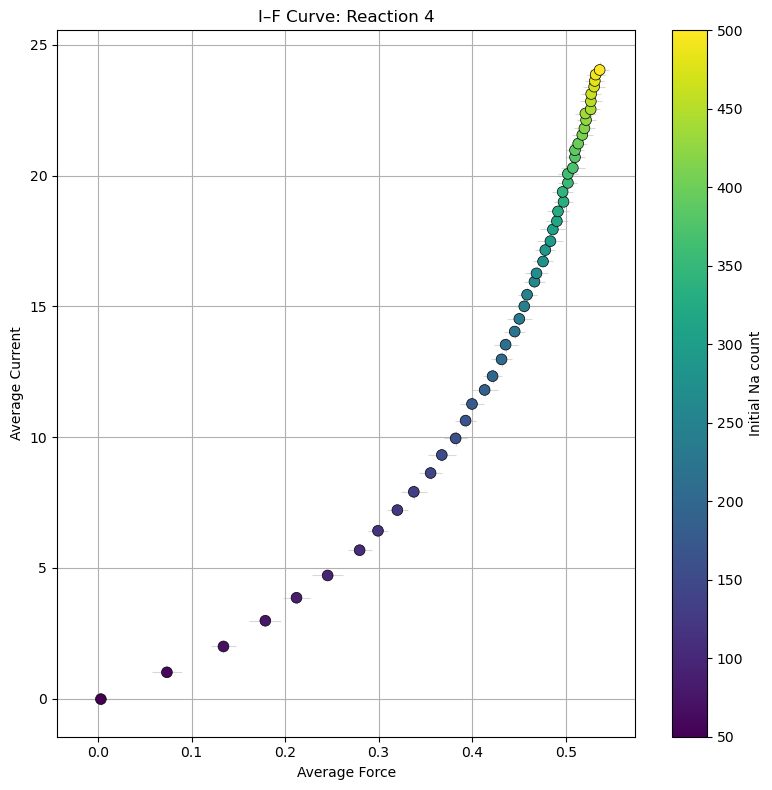

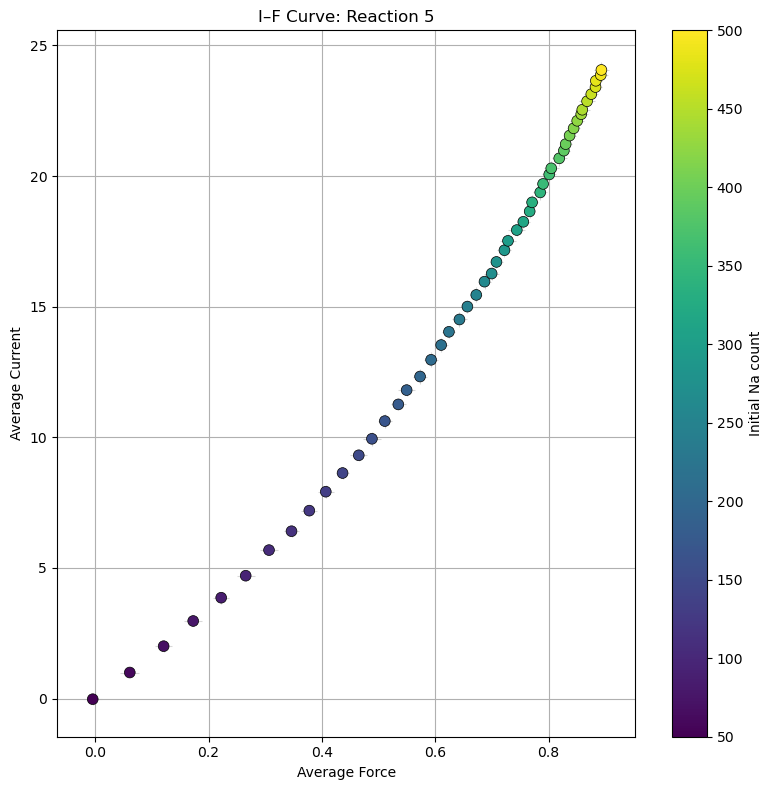

In [6]:
# Module 2

SIM2.plot_IF_curves(

        reaction_indices=None,
        analytical_currents=None,
        analytical_forces=None,
        show_errorbars=True,
        colour_by_count=True,
        marker_size=60,
        cmap='viridis'
    )

# Calculate and plot scalar or eigenvalues of conductance for inividual CRNs

In [7]:
# Calculate conductance of our individual CRNs. Again, we can opt to plot any analytical results for the conductance by passing the 
# currents and forces as lists into 'analytical_currents' and 'analytical_forces'.

SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

([Matrix([[5.39265702859725]]),
  Matrix([[5.37947538674217]]),
  Matrix([[5.39246674686675]]),
  Matrix([[5.38228373837103]]),
  Matrix([[5.26146941386191]]),
  Matrix([[5.16271326011337]]),
  Matrix([[5.00802082743484]]),
  Matrix([[4.84504339842451]]),
  Matrix([[4.70465107787117]]),
  Matrix([[4.49996489777917]]),
  Matrix([[4.3547497289697]]),
  Matrix([[4.21012421105227]]),
  Matrix([[4.09643618545716]]),
  Matrix([[3.94146608706126]]),
  Matrix([[3.79206532597579]]),
  Matrix([[3.66269987576188]]),
  Matrix([[3.540251289731]]),
  Matrix([[3.41472660417746]]),
  Matrix([[3.28538887740571]]),
  Matrix([[3.18467063604143]]),
  Matrix([[3.06694643771267]]),
  Matrix([[2.97068434656232]]),
  Matrix([[2.87795765509906]]),
  Matrix([[2.79393018239761]]),
  Matrix([[2.69374786323952]]),
  Matrix([[2.61127050030207]]),
  Matrix([[2.55142405242335]]),
  Matrix([[2.47306480309018]]),
  Matrix([[2.40388475525031]]),
  Matrix([[2.34215214574117]]),
  Matrix([[2.26855605906218]]),
  Matrix([[

In [8]:
SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

([Matrix([
  [11.9288453281423, 5.52707594637999],
  [5.52707594637999, 11.8496929355384]]),
  Matrix([
  [6.18474364858241, 2.85399880657149],
  [2.85399880657149, 10.4525246691524]]),
  Matrix([
  [ 6.4664542577892, 3.01515381897701],
  [3.01515381897701,  10.582082980246]]),
  Matrix([
  [6.84501553552441, 3.20087954204057],
  [3.20087954204057, 10.4606904544899]]),
  Matrix([
  [7.11756039533525, 3.30781195254655],
  [3.30781195254655, 10.4546547060696]]),
  Matrix([
  [7.32439845050928, 3.41249512835483],
  [3.41249512835483,  10.500312877219]]),
  Matrix([
  [7.59235075224352, 3.57208755975657],
  [3.57208755975657, 10.4341525831564]]),
  Matrix([
  [7.72895060942888, 3.62905919970274],
  [3.62905919970274, 10.3917038819777]]),
  Matrix([
  [7.94169379390548, 3.73952736810308],
  [3.73952736810308, 10.3509303894669]]),
  Matrix([
  [8.11091767093153, 3.80818455208718],
  [3.80818455208718, 10.3149171241147]]),
  Matrix([
  [8.25508323685487, 3.90386677932494],
  [3.90386677932494

No difference plotted: Option Deprecated


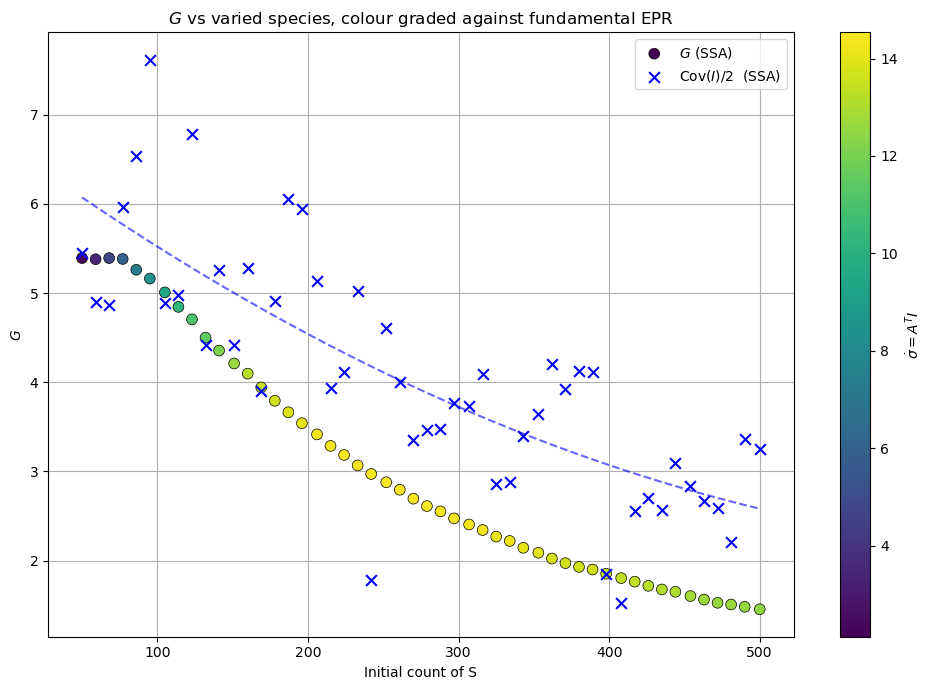

In [10]:
# Plot the conductances. For module 1, we expect a scalar value, so the code will plot this scalar conductance vs the count values.
# We can opt to plot the covariance of the currents and forces with 'show_covariance=True', this plots Cov(I)/2. Also, we can plot
# the difference between the numerical and analytical conductances with 'show_difference=True', this plots the value |G - Cov(I)/2|. 
# We can also fit a polynomial of order 'fit_order' to the numerical conductance values.

# Module 1

SIM1.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )



No differenec plotted: Option Deprecated.


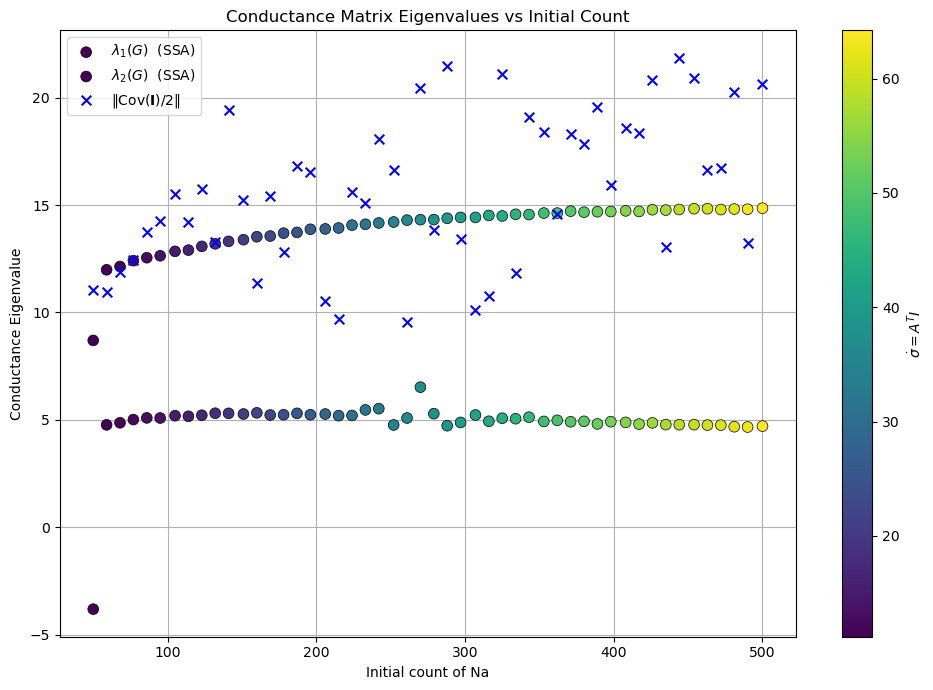

In [ ]:
# The code automatically detects whether the conductance is scalar or a matrix.

# Module 2

SIM2.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )

# Numerical Conductance of Serially Connected CRNs

In [11]:
# First, create the following module variables for the two CRNs we want to combine.

module1_for_simulating = ModuleProperties(SM, 3, species_names)

module2_for_simulating = ModuleProperties(SM2, 4, species_names2)

# We must create the individual resistance matrices for each module before combining them

module1_for_simulating.calculate_fundamental_resistance_matrix() 

module2_for_simulating.calculate_fundamental_resistance_matrix()

# Then prepare the module variables for simulation

SIM1 = RunSSA(module1_for_simulating, initial_counts, rates, simulation_length, burn_in_time)

SIM2 = RunSSA(module2_for_simulating, initial_counts2, rates2, simulation_length, burn_in_time)



In [12]:
module2_for_simulating.species_names

['Eb', 'EbF', 'EbW', 'Eb*', 'Na', 'Nb', 'F', 'W']

In [ ]:
# Compute data that will be combined. Here vary Na over the same values in both (the overlapping species).

# Module 1

SIM1.run_IF_sweep(
    
        species_index=3,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=50, 
        covariance_reaction_indices=[0],   
        verbose=True)

# Module 2

SIM2.run_IF_sweep(
    
        species_index=4,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=50, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

Sweep 1/50  ([Na] = 50)
Sweep 2/50  ([Na] = 59)
Sweep 3/50  ([Na] = 68)
Sweep 4/50  ([Na] = 77)
Sweep 5/50  ([Na] = 86)
Sweep 6/50  ([Na] = 95)
Sweep 7/50  ([Na] = 105)
Sweep 8/50  ([Na] = 114)
Sweep 9/50  ([Na] = 123)
Sweep 10/50  ([Na] = 132)
Sweep 11/50  ([Na] = 141)
Sweep 12/50  ([Na] = 151)
Sweep 13/50  ([Na] = 160)
Sweep 14/50  ([Na] = 169)
Sweep 15/50  ([Na] = 178)
Sweep 16/50  ([Na] = 187)
Sweep 17/50  ([Na] = 196)
Sweep 18/50  ([Na] = 206)
Sweep 19/50  ([Na] = 215)
Sweep 20/50  ([Na] = 224)
Sweep 21/50  ([Na] = 233)
Sweep 22/50  ([Na] = 242)
Sweep 23/50  ([Na] = 252)
Sweep 24/50  ([Na] = 261)
Sweep 25/50  ([Na] = 270)
Sweep 26/50  ([Na] = 279)
Sweep 27/50  ([Na] = 288)
Sweep 28/50  ([Na] = 297)
Sweep 29/50  ([Na] = 307)
Sweep 30/50  ([Na] = 316)
Sweep 31/50  ([Na] = 325)
Sweep 32/50  ([Na] = 334)
Sweep 33/50  ([Na] = 343)
Sweep 34/50  ([Na] = 353)
Sweep 35/50  ([Na] = 362)
Sweep 36/50  ([Na] = 371)
Sweep 37/50  ([Na] = 380)
Sweep 38/50  ([Na] = 389)
Sweep 39/50  ([Na] = 398)
S

(array([[19.36951444, -5.10987191, 19.32284895, 24.41272135, 24.49938585],
        [18.94660108, -5.43331453, 19.03993409, 24.4399154 , 24.48991523],
        [19.20313539, -4.78995063, 19.23646838, 24.00641922, 23.96975293],
        [19.17964552, -4.86324345, 18.99631558, 23.98955663, 23.97622354],
        [18.6597347 , -5.12992706, 18.64973484, 23.83632776, 23.7563289 ],
        [19.23656694, -4.95330765, 19.2065671 , 24.16654138, 24.07320853],
        [19.3598638 , -4.83329933, 19.42319669, 24.22316292, 24.24316278],
        [19.46976932, -4.72661067, 19.20643911, 24.20971316, 24.16971364],
        [18.69942645, -5.02317926, 18.68942676, 23.69260663, 23.70927279],
        [19.31984958, -5.08662706, 19.34318273, 24.38314349, 24.40314334],
        [19.01986679, -5.32329605, 18.989867  , 24.3631627 , 24.31649636],
        [19.10988013, -4.67330402, 18.99654751, 23.77651752, 23.68651809],
        [19.66967033, -4.9399172 , 19.64300411, 24.58958787, 24.67625308],
        [19.12986441, -5.

In [23]:
# Compute lists of the numerical conductance for each module, we will not overlay any analytical results.

module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

In [24]:
# Now we use the CombiningModules class to combine the data from the two modules, this essentially involves replacing the symbolic
# values of resistance with the numerical results calculated above, and the same code as the symbolic case follows.

module3 = CombiningModules(module1_for_simulating, module2_for_simulating, module1_conductances, module2_conductances)

# Store the numerical combined condictance matrices

combined_Gs = module3.numerical_combined_fundamental_CMs# Acquire the serially combined conductance matrix

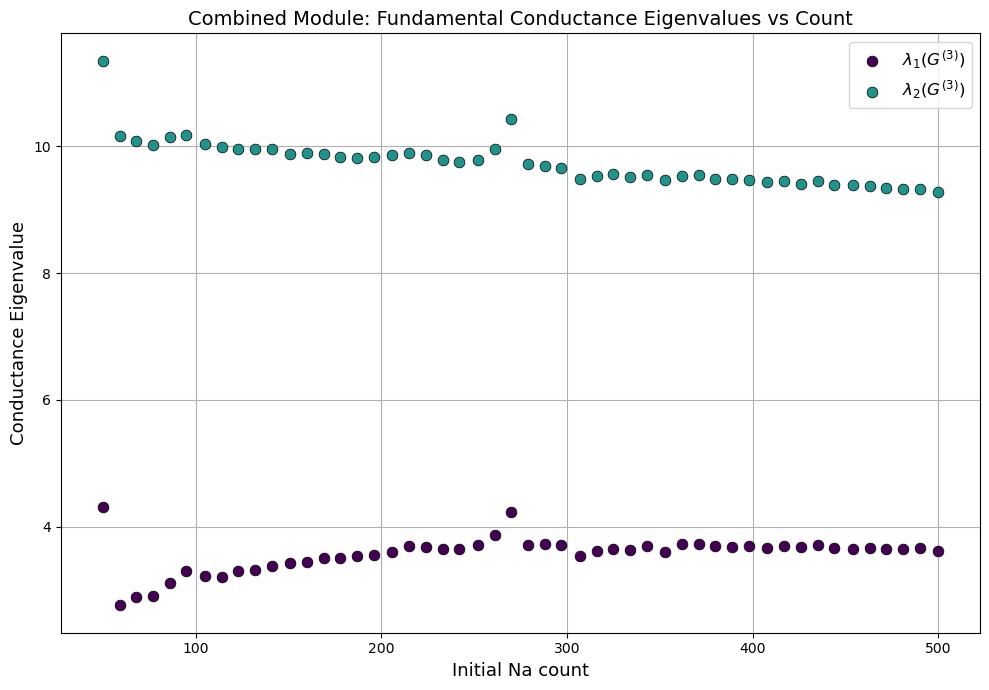

In [25]:
# Use a dedicated function to plot this combined conductance. It is important to include the same count_values as the
# compute_conductances attribute used, and include the species label that is being varied. If the combined_Gs is scalar, this will
# plot a simple line of conductance vs count, if it is a list of matrices, this will plot the eigenvalues of these matrices.

plot_combined_conductance(
    combined_CMs  = combined_Gs,
    count_values  = np.linspace(50, 500, 50, dtype='int'),
    species_label ='Na'
)

### Plotting the conductance directly from the joint SM

In [4]:
# Re-define the module variables for clarity, and calculate their fundamental resistance matrix.

m1 = ModuleProperties(SM, 3, species_names)

m1.calculate_fundamental_resistance_matrix()

m2 = ModuleProperties(SM2, 4, species_names2)

m2.calculate_fundamental_resistance_matrix()

⎡r₂ + r₄ + r₅      -r₂     ⎤
⎢                          ⎥
⎣    -r₂       r₁ + r₂ + r₃⎦

In [5]:
m3 = CombiningModules(m1,m2,left_mod_numerical_CM=None,right_mod_numerical_CM=None) # order matters! Require Left feeds into Right

module3_for_simulating = ModuleProperties(m3.stoich_matrix, m3.num_internal_species, m3.species_names)

In [6]:
# Create combined rates and counts

combined_initial_counts, combined_rates = m3.build_combined_initial_counts_and_rates(
    left_initial_counts  = initial_counts,
    right_initial_counts = initial_counts2,
    left_rates = rates,
    right_rates = rates2
)


=== Overlapping species detected ===
  ['Na']
These species appear in both modules and are now internal.
Please enter a single initial count for each:

  Species 'Na':
    Left  module value : 50
    Right module value : 50



=== Combined initial counts ===
  [0] Ea           : 350
  [1] EaS          : 350
  [2] EaS2         : 350
  [3] Na           : 50.0 ← user entered
  [4] Eb           : 350
  [5] EbF          : 350
  [6] EbW          : 350
  [7] Eb*          : 350
  [8] S            : 50
  [9] Nb           : 50
  [10] F            : 50
  [11] W            : 50

=== Combined rates ===
  Reaction  1 (left ) : k+ = 0.0005,  k- = 0.08
  Reaction  2 (left ) : k+ = 0.06,  k- = 0.0002
  Reaction  3 (left ) : k+ = 0.0012,  k- = 0.05
  Reaction  4 (right) : k+ = 0.001,  k- = 0.1
  Reaction  5 (right) : k+ = 0.1,  k- = 0.05
  Reaction  6 (right) : k+ = 0.15,  k- = 0.001
  Reaction  7 (right) : k+ = 0.001,  k- = 0.1
  Reaction  8 (right) : k+ = 0.12,  k- = 0.001


In [7]:
# Create simulation module variable

SIM3 = RunSSA(module3_for_simulating, combined_initial_counts, combined_rates, 400, 100)

In [31]:
# determine which currents are in the fundamental current vector for this module. We see it is [5,7] (currents j6 and j8)

module3_for_simulating.fundamental_current_vector

⎡-j₈⎤
⎢   ⎥
⎣-j₆⎦

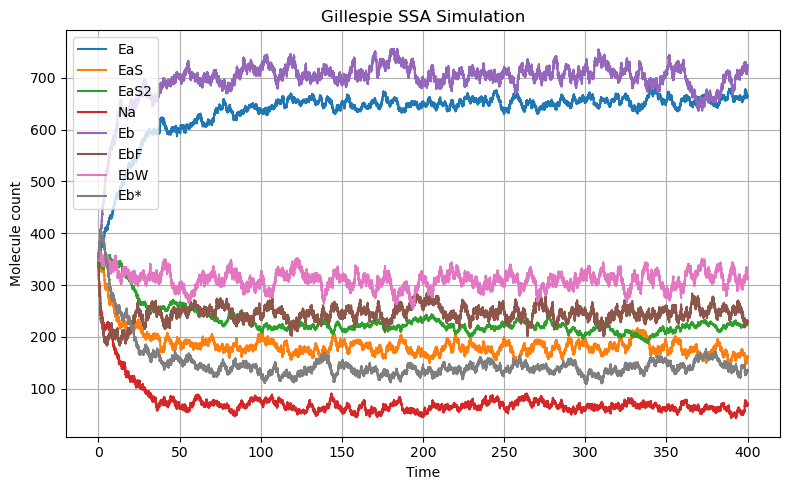

In [32]:
# We can plot the combined module

SIM3.run_SSA_and_plot_counts(store_trajectories=True, starting_pops=None)

In [10]:
# And again run the sim over many values of a specified species to see the conductance changes (let's try 'S' and 'Nb', as these
# are external species. This is indexes = 8,9 (varying over the same quantity). And lets ignore covariance for now.

# Run the sweep

SIM3.run_IF_sweep(
    
        species_index=8,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=300, 
        covariance_reaction_indices=[5,7],   
        verbose=True)




Sweep 1/50  ([S] = 50)
Sweep 2/50  ([S] = 59)
Sweep 3/50  ([S] = 68)
Sweep 4/50  ([S] = 77)
Sweep 5/50  ([S] = 86)
Sweep 6/50  ([S] = 95)
Sweep 7/50  ([S] = 105)
Sweep 8/50  ([S] = 114)
Sweep 9/50  ([S] = 123)
Sweep 10/50  ([S] = 132)
Sweep 11/50  ([S] = 141)
Sweep 12/50  ([S] = 151)
Sweep 13/50  ([S] = 160)
Sweep 14/50  ([S] = 169)
Sweep 15/50  ([S] = 178)
Sweep 16/50  ([S] = 187)
Sweep 17/50  ([S] = 196)
Sweep 18/50  ([S] = 206)
Sweep 19/50  ([S] = 215)
Sweep 20/50  ([S] = 224)
Sweep 21/50  ([S] = 233)
Sweep 22/50  ([S] = 242)
Sweep 23/50  ([S] = 252)
Sweep 24/50  ([S] = 261)
Sweep 25/50  ([S] = 270)
Sweep 26/50  ([S] = 279)
Sweep 27/50  ([S] = 288)
Sweep 28/50  ([S] = 297)
Sweep 29/50  ([S] = 307)
Sweep 30/50  ([S] = 316)
Sweep 31/50  ([S] = 325)
Sweep 32/50  ([S] = 334)
Sweep 33/50  ([S] = 343)
Sweep 34/50  ([S] = 353)
Sweep 35/50  ([S] = 362)
Sweep 36/50  ([S] = 371)
Sweep 37/50  ([S] = 380)
Sweep 38/50  ([S] = 389)
Sweep 39/50  ([S] = 398)
Sweep 40/50  ([S] = 408)
Sweep 41/50  ([

(array([[ 3.94328113e+00,  3.95661429e+00,  2.33330244e-02, ...,
          1.15831800e+01,  3.95661429e+00,  3.96328087e+00],
        [ 3.92661679e+00,  3.94661654e+00,  1.99997460e-02, ...,
          1.16065192e+01,  3.95994970e+00,  3.89328388e+00],
        [ 3.81662130e+00,  3.80328813e+00, -9.99988114e-03, ...,
          1.16765279e+01,  3.77662178e+00,  3.66328979e+00],
        ...,
        [ 3.71331920e+00,  3.69331927e+00,  9.99996193e-03, ...,
          1.17032888e+01,  3.66998603e+00,  3.70331923e+00],
        [ 4.15996568e+00,  4.17996552e+00, -3.99996700e-02, ...,
          1.19465681e+01,  4.09996618e+00,  4.11329940e+00],
        [ 4.04663019e+00,  4.06329671e+00,  3.33330329e-03, ...,
          1.16732281e+01,  4.12996278e+00,  4.12662947e+00]]),
 array([[ 4.83682281e-01,  1.91092124e+00, -2.74026464e-02, ...,
          2.65749965e-01,  2.32226631e-01,  2.08330888e-01],
        [ 4.92825479e-01,  1.92782329e+00,  5.59884748e-04, ...,
          2.76963086e-01,  1.96917087e

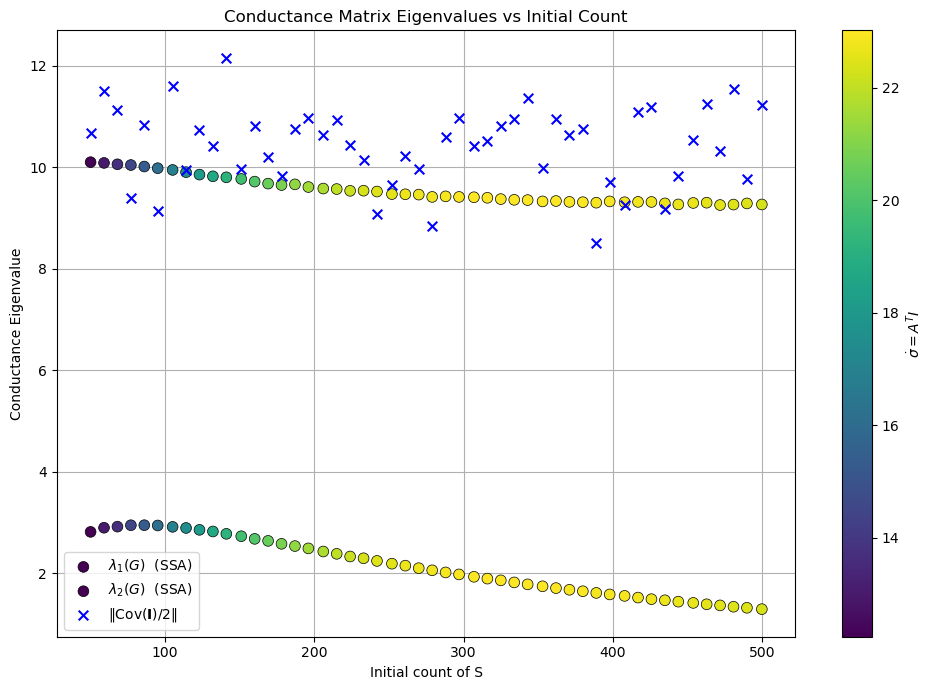

In [11]:
# Compute the conductance and plot.

SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)

SIM3.plot_conductance(
        analytical_G=None,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=False
    )

# Plotting Pre-Calculated Analytical Data

In [ ]:
# But let's say we want to overlay some analytical data. For module 1, we can solve the steady state equations and calculate the 
# currents and forces as below, then we can pass these into the attribute to get an overlay.

rates = rates
k1f = rates[0]
k1b = rates[1]
k2f = rates[2]
k2b = rates[3]
k3f = rates[4]
k3b = rates[5]

S = 50

E_T = 350*3 #initial_counts[0] + initial_counts[1] + initial_counts[2] # total internal species (shouldn't change due to conservation)

analytical_current1 = []
analytical_force1 = []

analytical_current2 = []
analytical_force2 = []

analytical_current3 = []
analytical_force3 = []

Na_counts = np.linspace(50,500,50,dtype='int')

for Na in Na_counts:

    chi = (k2f + k1b)/(k1f*S + k2b*Na)

    j1 = (k1f*k2f*S - k1b*k2b*Na)*E_T / (((k1f*S + k2b*Na)*(1+ k3f*S/k3b))+k2f+k1b)

    f1 = np.log( (k1f*S*(k1b+k2f)) / (k1b*(k1f*S + k2b*Na)) )

    j2 = (E_T *k2f - E_T*k2b*Na*chi)/(1 + chi + k3f*S/k3b )
    
    f2 = np.log( (k2f*(k1f*S + k2b*Na) / (k2b*Na*(k2f + k1b)) ))

    j3 = 0

    f3 = 0

    analytical_current1.append(j1)
    analytical_force1.append(f1)

    analytical_current2.append(j2)
    analytical_force2.append(f2)

    analytical_current3.append(j3)
    analytical_force3.append(f3)

an_currents = [analytical_current1, analytical_current2, analytical_current3]
an_forces = [analytical_force1, analytical_force2, analytical_force3]

Sweep 1/50  ([S] = 50)
Sweep 2/50  ([S] = 59)
Sweep 3/50  ([S] = 68)
Sweep 4/50  ([S] = 77)
Sweep 5/50  ([S] = 86)
Sweep 6/50  ([S] = 95)
Sweep 7/50  ([S] = 105)
Sweep 8/50  ([S] = 114)
Sweep 9/50  ([S] = 123)
Sweep 10/50  ([S] = 132)
Sweep 11/50  ([S] = 141)
Sweep 12/50  ([S] = 151)
Sweep 13/50  ([S] = 160)
Sweep 14/50  ([S] = 169)
Sweep 15/50  ([S] = 178)
Sweep 16/50  ([S] = 187)
Sweep 17/50  ([S] = 196)
Sweep 18/50  ([S] = 206)
Sweep 19/50  ([S] = 215)
Sweep 20/50  ([S] = 224)
Sweep 21/50  ([S] = 233)
Sweep 22/50  ([S] = 242)
Sweep 23/50  ([S] = 252)
Sweep 24/50  ([S] = 261)
Sweep 25/50  ([S] = 270)
Sweep 26/50  ([S] = 279)
Sweep 27/50  ([S] = 288)
Sweep 28/50  ([S] = 297)
Sweep 29/50  ([S] = 307)
Sweep 30/50  ([S] = 316)
Sweep 31/50  ([S] = 325)
Sweep 32/50  ([S] = 334)
Sweep 33/50  ([S] = 343)
Sweep 34/50  ([S] = 353)
Sweep 35/50  ([S] = 362)
Sweep 36/50  ([S] = 371)
Sweep 37/50  ([S] = 380)
Sweep 38/50  ([S] = 389)
Sweep 39/50  ([S] = 398)
Sweep 40/50  ([S] = 408)
Sweep 41/50  ([

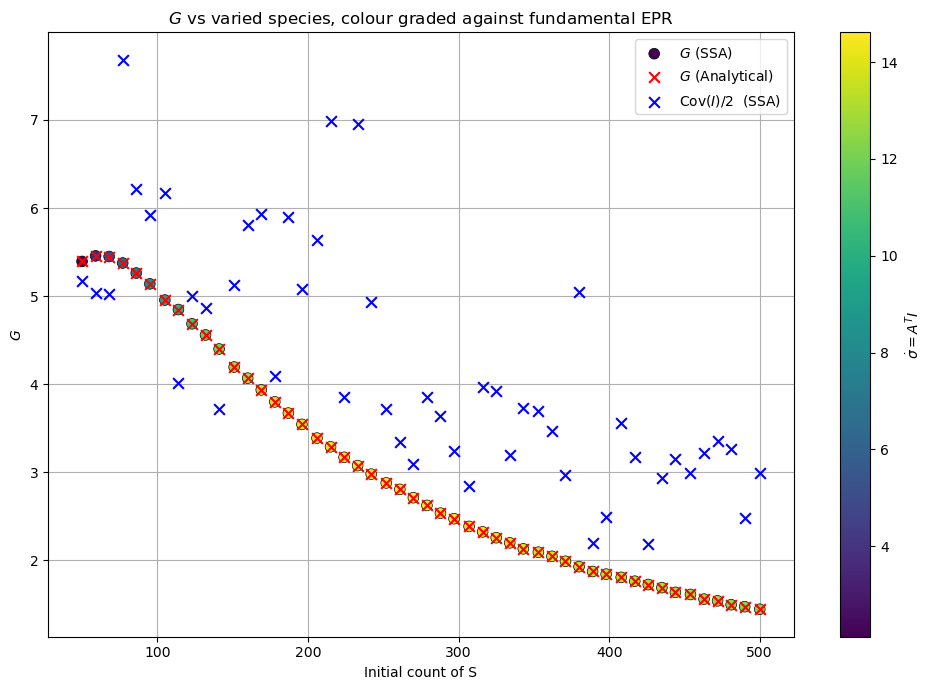

In [ ]:
# Now pass these through the calculating attribute and store the result

SIM1.run_IF_sweep(
    
        species_index=3,
        count_values=np.linspace(50,500,50,dtype='int'),
        total_iterations=50, 
        covariance_reaction_indices=[0],   
        verbose=True)

_, an_conductances = SIM1.compute_conductances(an_currents, an_forces)

# And plot, with an_conductances passed.

SIM1.plot_conductance(
        analytical_G=an_conductances,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )